Multi-fidelity Modeling and Experimental Design (Active Learning)

In [14]:
# General imports

import numpy as np
np.random.seed(20)
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import colors as mcolors
colors = dict(mcolors.BASE_COLORS, **mcolors.CSS4_COLORS)
import sys
import os

import gp_regression_surrogate_model as mfsm
from emukit.multi_fidelity.convert_lists_to_array import convert_x_list_to_array

In [15]:
version = 'vgp1.1'
file_in=f'Ge77_rates_CNP_{version}.csv'
if not os.path.exists(f'out/{version}'):
   os.makedirs(f'out/{version}')

   

# Set parameter name/x_labels -> needs to be consistent with data input file
#x_labels=['Radius[cm]','Thickness[cm]','Theta[deg]','Length[cm]']
x_labels=['Radius[cm]','Thickness[cm]','NPanels', 'Theta[deg]', 'Length[cm]']

y_label_sim = 'rGe77[nuc/(kg*yr)]'

# Set parameter boundaries
xmin=[0,0,0,0]
xmax=[265,20,90,150]
#xmax=[265,20,360,90,150]

# Set parameter boundaries for aquisition function
xlow=[90,4,0,0]
xhigh=[250,20,90,150]
#xhigh=[250,15,360,90,150]

# Assign costs
low_fidelity_cost = 1.
high_fidelity_cost = 2000.

# Set a fixed point in space for drawings
x_fixed = [160, 2, 45, 20]
#x_fixed = [160, 2, 40, 45, 20]
# number of sigma for error band drawing on prediction
factor=1.

# Get LF noise from file
#with open(f'in/{file_in}') as f:
#    first_line = f.readline()
#LF_noise=np.round(float(first_line.split(' +')[0].split('= ')[1]),3)

# Get HF and LF data samples from file
data=pd.read_csv(f'in/{file_in}')
#data=data[[f'Mode', x_labels[0], x_labels[1], x_labels[2], x_labels[3], x_labels[4],'Ge77-Rate[nucleus/(kg yr)]']]

data=pd.read_csv(f'in/{file_in}')
data=data[[f'Mode', x_labels[0], x_labels[1], x_labels[2], x_labels[3] ,x_labels[4],y_label_sim]]


#LF_noise=np.mean(data.loc[data['Mode']==0.][y_err_label_cnp].to_numpy())
#HF_noise=np.mean(data.loc[data['Mode']==1.][y_err_label_cnp].to_numpy())

In [16]:

x_train_h, y_train_h = ([],[])
row_h=data.index[data['Mode'] == 1].tolist()

x_train_hf_sim = data.loc[data['Mode']==1.][x_labels].to_numpy().tolist()
y_train_hf_sim = data.loc[data['Mode']==1.][y_label_sim].to_numpy().tolist()

x_train_hf_sim, y_train_hf_sim = (np.atleast_2d(x_train_hf_sim), np.atleast_2d(y_train_hf_sim).T)



In [17]:
sys.path.append('../utilities')
import simulation_utils as sim

In [18]:
for i,x in enumerate(x_train_hf_sim):
    print(x)
    sim.print_geant4_macro(x,f"{310+i}",mode="LF",version="v1.4")

[98.   9.5 46.  10.6  4.9]
[225.   12.5 155.   25.1  12. ]
[176.5   9.8  41.   20.5  15. ]
[163.2   5.5 140.   71.1   3.8]
[210.3  14.3 151.    5.5   4.3]
[168.6  17.2 126.   19.3   6.9]
[191.8  14.9 238.   41.9   2.2]
[231.3   8.8 116.   41.8  13.9]
[247.5  15.8 137.   35.3   2.6]
[182.5   5.1 273.   70.3   9.9]
[184.1  13.5  14.   27.4  11.7]
[217.9  16.4 274.    4.6   2.8]
[100.4  14.2  43.    6.5  14.9]
[243.9  12.3 107.    8.3   9.4]
[190.5   5.9 117.   78.3   6.2]
[252.5  10.7 357.   10.3   4.6]
[204.1   6.8  31.    6.6  99.5]
[201.2  12.4 233.   71.9   3.5]
[229.4   9.5 117.   25.6  22.7]
[188.8  13.2  12.    9.3   2.5]
[170.4  14.8 145.   65.9   2.1]
[180.   18.   34.   22.7   3. ]
[229.   16.2  23.    5.4  20.2]
[249.   11.7  78.   31.3  12.7]
[129.2  11.6  73.   80.4   2.5]
[175.1  15.9 210.    9.8   3.4]
[232.2   9.8 212.   45.3   6.1]
[105.6   6.5  39.   83.2  11.1]
[136.6   6.6  24.   10.4  48.5]
[165.6   7.  168.   46.8  17.1]
[177.4  12.7 269.   43.8   2.2]
[209.9  14.  

In [20]:
mf_model = mfsm.linear_multi_fidelity_model(x_train_hf_sim, y_train_hf_sim)

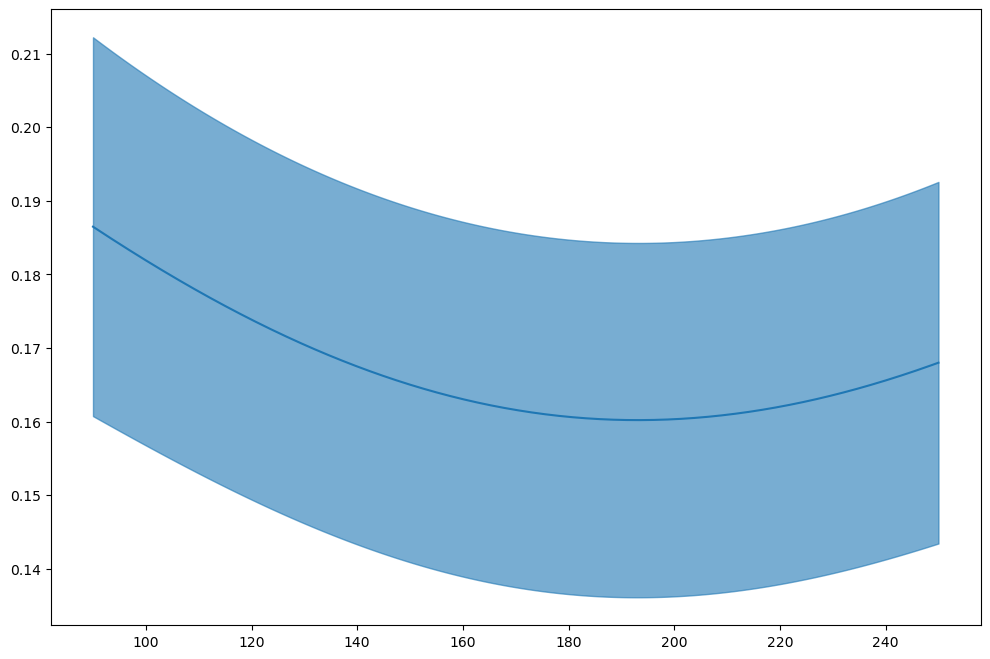

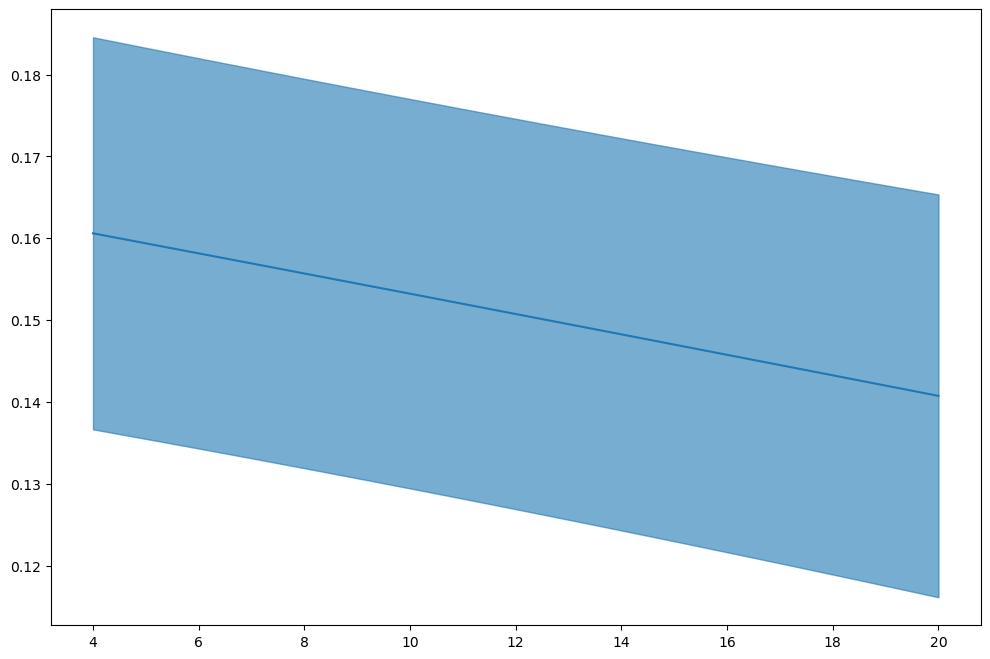

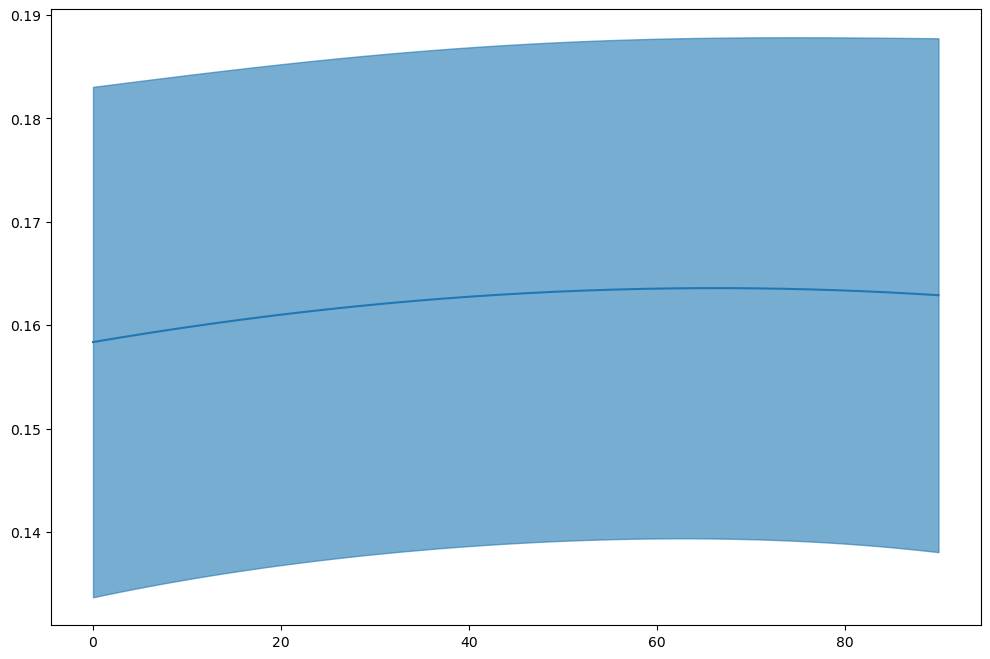

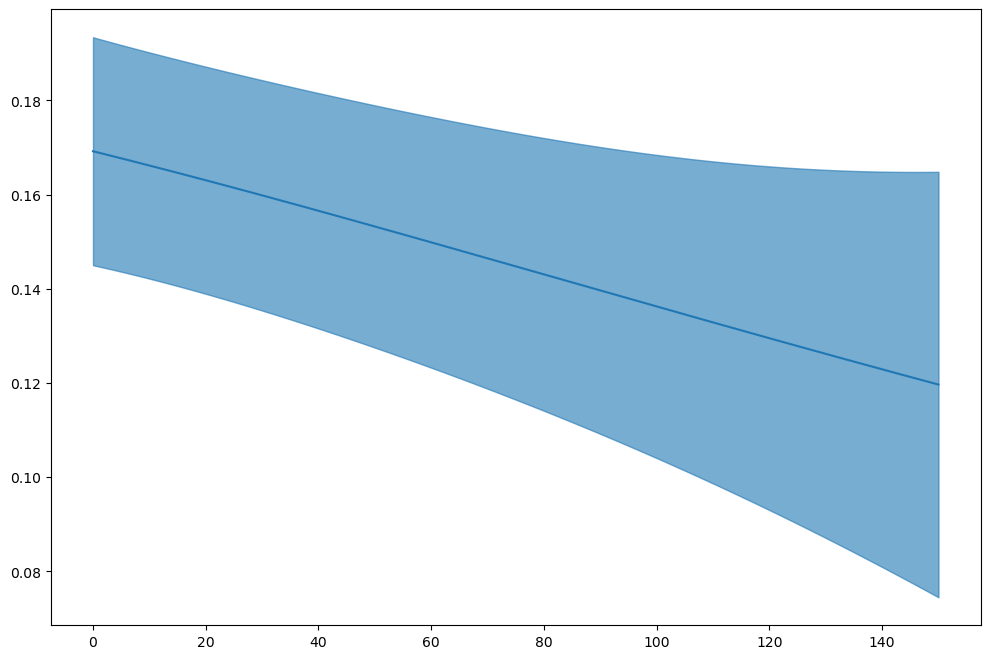

In [21]:
SPLIT = 500
for i in range(len(x_labels)):  
        x_labels2 = ["r","b","N","$\theta$","L"]
        x_fix_tmp = [str(round(x,1)) for x in x_fixed]
        x_fix_tmp[i] = x_labels2[i]
        label_tmp = r"Projection on x(r,b,N,$\theta$,L)=["
        for x in x_fix_tmp[:-1]:
            label_tmp += fr"{x},"
        label_tmp += f"{x_fix_tmp[-1]}]"
        ## Compute mean and variance predictions
        x_plot=[x_fixed[:] for l in range(0,SPLIT)]
        x_tmp = np.linspace(xlow[i], xhigh[i], SPLIT)
        for k in range(0,SPLIT):
            x_plot[k][i]=x_tmp[k]
        x_plot = (np.atleast_2d(x_plot))

        hf_mean_mf_model, hf_var_mf_model = mf_model.predict(x_plot)
        hf_std_mf_model = np.sqrt(hf_var_mf_model)
        plt.figure(figsize=(12, 8))
        plt.fill_between(x_plot[:, i],
                hf_mean_mf_model[:, 0] + hf_std_mf_model[:, 0],
                hf_mean_mf_model[:, 0] - hf_std_mf_model[:, 0], color="C0", alpha=0.6)
        plt.plot(x_plot[:,i], hf_mean_mf_model, "C0", label="Model")
    



In [22]:
%%capture
leg_label = []
ncol=1
nrow=int(np.ceil(len(x_labels)/ncol))
fig1,ax1  = plt.subplots(nrow,ncol, figsize=(5, 12),layout="constrained")
fig2,ax2  = plt.subplots(nrow,ncol, figsize=(5, 12),layout="constrained")

In [23]:
add_new_sample=True
sample=0
total_samples=20

In [24]:

while ( sample < total_samples and sample <= max(mfsm.get_num_new_samples(version)[0],mfsm.get_num_new_samples(version)[1])+1 ):
    print('Sample #', sample)
    # add new data point to training data and update model with new training data
    x_new_data=np.array([])
    y_new_data_h=np.array([])
    #if sample > 0:
    #    x_train_hf_sim, y_train_hf_sim, mf_model = mfsm.add_samples(x_train_hf_sim, y_train_hf_sim, mf_model, x_labels, y_label_sim ,sample-1, version)

    # run the model drawing
    draw_mfsm.draw_model(mf_model, xmin, xmax, x_labels, factor, version)#
    #fig1 = draw_mfsm.draw_model_updated(fig1, mf_model, xmin, xmax, x_labels, factor, version, x_fixed=x_fixed)
    sample+=1



FileNotFoundError: [Errno 2] No such file or directory: 'in/Ge77_rates_new_samples_v2.0.csv'